In [1]:
import os
import gc
import torch
import shutil
os.environ["CUDA_VISIBLE_DEVICES"] = "0,2"

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from trl import setup_chat_format
from huggingface_hub import HfApi

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format
import copy

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
def merge_lora_adapter(
    lora_model, 
    base_model, 
    save_on_disk=True, 
    upload_to_HF=False,
    **kwargs_HF
):
    save_path = None
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForCausalLM.from_pretrained(
        base_model,
        device_map="auto",
        trust_remote_code=True
    )

    if tokenizer.chat_template is None:
        model, tokenizer = setup_chat_format(model, tokenizer)

    # Load LoRA on top of base
    model = PeftModel.from_pretrained(model, lora_model)

    # Merge LoRA adapters into the base model
    model = model.merge_and_unload()

    if save_on_disk:
        save_path = os.path.join(lora_model, "lora_merged")
        model.save_pretrained(save_path, safe_serialization=True)
        tokenizer.save_pretrained(save_path)

        # the modeling_gpt2.py file is missing after merge,
        # therefore it is copied manually
        custom_modeling_src = "/home/behzad_shomali/modalities/src/modalities/instruction_finetuning/modeling_gpt2.py"
        custom_modeling_dst = os.path.join(save_path, "modeling_gpt2.py")
        shutil.copy(custom_modeling_src, custom_modeling_dst)

    if upload_to_HF:
        revision = kwargs_HF["revision"]
        repo_id = kwargs_HF["repo_id"]
        commit_message = kwargs_HF.get("commit_message", "Add merged LoRA model with custom code")

        model.push_to_hub(
            repo_id,
            revision=revision,
            private=True,
            use_temp_dir=True, # makes sure full files are synced
            commit_message=commit_message,
            safe_serialization=True
        )
        tokenizer.push_to_hub(repo_id, revision=revision)

        api = HfApi()
        api.upload_file(
            path_or_fileobj="/home/behzad_shomali/modalities/src/modalities/instruction_finetuning/modeling_gpt2.py",       
            repo_id=repo_id,  
            path_in_repo="modeling_gpt2.py",     
            repo_type="model",
            revision=revision
        )

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    return save_path

def apply_merge_on_all_checkpints(base_model, experiment_dir):
    for directory in os.listdir(experiment_dir):
        if directory.startswith("checkpoint"):
            checkpoint_dir = os.path.join(experiment_dir, directory)
            if any(["lora_merged" in sub_dir for sub_dir in os.listdir(checkpoint_dir)]):
                continue
            print("Merging:", checkpoint_dir)
            merge_lora_adapter(
                lora_model=checkpoint_dir, 
                base_model=base_model,
                save_on_disk=True,
                upload_to_HF=False
            )

In [3]:
# lora_model = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-30000/"
# lora_model = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/_lora+_rank16_alpha32_1M(Markus)/2025_09_10-12_02_25_lora+_rank16_alpha32_1M(Markus)/2025_09_10-13_00_59/"
lora_model = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/_lora+_rank16_alpha32_1M(Markus)/2025_09_10-20_00_40/checkpoint-12000/"
base_model = "Behzadshomali/Teuken3.7B"

tokenizer = AutoTokenizer.from_pretrained(base_model)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model,
    device_map="auto",
    trust_remote_code=True
)
# merged_model = AutoModelForCausalLM.from_pretrained(
#     f"{lora_model}/lora_merged",
#     device_map="auto",
#     trust_remote_code=True
# )

if tokenizer.chat_template is None:
    base_model, tokenizer = setup_chat_format(base_model, tokenizer)

# Load LoRA on top of base
peft_model = PeftModel.from_pretrained(copy.deepcopy(base_model), lora_model)
merged_model = AutoModelForCausalLM.from_pretrained(
    f"{lora_model}/lora_merged",
    device_map="auto",
    trust_remote_code=True
)

A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.96s/it]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and 

In [4]:
input_text2 = "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left? Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left? Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left? Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left? Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?"
inputs2 = tokenizer(input_text2, return_tensors="pt")

with torch.no_grad():
    out_runtime2 = peft_model(**inputs2, output_hidden_states=False, return_dict=True)
    logits_runtime2 = out_runtime2.logits.cpu()

    out_merged2 = merged_model(**inputs2, output_hidden_states=False, return_dict=True)
    logits_merged2 = out_merged2.logits.cpu()

input_text = "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?"
inputs = tokenizer(input_text, return_tensors="pt")

with torch.no_grad():
    out_runtime = peft_model(**inputs, output_hidden_states=False, return_dict=True)
    logits_runtime = out_runtime.logits.cpu()

    out_merged = merged_model(**inputs, output_hidden_states=False, return_dict=True)
    logits_merged = out_merged.logits.cpu()



In [5]:
from transformers import pipeline

In [52]:
pipe_merged = pipeline(
    "text-generation", 
    model=merged_model, 
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16, 
    device_map="cuda:0", 
    max_length=500,
    do_sample=False,
    # temperature=0
)

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The model 'GPT2ForCausalLM' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausa

In [53]:
pipe_adapter = pipeline(
    "text-generation", 
    model=peft_model, 
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16, 
    device_map="cuda:0", 
    max_length=500,
    do_sample=False,
    # temperature=0
)

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [5]:
prompts = [
    "The answer of 5/5+5+5*4 is calculated as:",
    "Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?",
    "Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?",
    "Julie is reading a 120-page book. Yesterday, she was able to read 12 pages and today, she read twice as many pages as yesterday. If she wants to read half of the remaining pages tomorrow, how many pages should she read?",
    "James writes a 3-page letter to 2 different friends twice a week. How many pages does he write a year?",
    "Albert is wondering how much pizza he can eat in one day. He buys 2 large pizzas and 2 small pizzas. A large pizza has 16 slices and a small pizza has 8 slices. If he eats it all, how many pieces does he eat that day?",
    "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?",
    "Amanda needs 12 more marbles to have twice as many marbles as Katrina, and Mabel has 5 times as many marbles as Katrina. If Mabel has 85 marbles, how many more marbles does Mabel have than Amanda?",
    "Ken had fifty pencils, and he wanted to share some of them with his two friends, Manny and Nilo. Ken gave ten pencils to Manny and ten more pencils to Nilo than he gave to Manny. He kept the rest of the pencils. How many pencils did Ken keep?",
    "Reggie and his brother are having a basketball shooting contest. They each get to take 10 shots. Layups are worth 1 point, free throws are worth 2 points, and anything further away is worth 3 points. Reggie makes 3 layups, two free throws, and one long shot. His brother only shoots long shots and makes 4 of them. How many points does Reggie lose by?",
   "Mr. Caiden wants to do repairs to his house and requires 300 feet of metal roofing to do this. If each foot of roofing costs $8, and the supplier of the metal roofing brings in 250 feet of metal roofing for free, how much money is Mr. Caiden required to pay for the remaining metal roofing?"

]

In [50]:
def convert_prompt_to_message(prompt, few_shots=[]):
    few_shot_prompt = ""
    for shot in few_shots:
        few_shot_prompt += shot["question"]
        few_shot_prompt += "\n\n"
        few_shot_prompt += shot["answer"]
        few_shot_prompt += "\n\n\n"
    

    messages = [
        {"role": "user", "content": f"{few_shot_prompt}{prompt}"}
    ]

    return messages
prompt = convert_prompt_to_message(prompts[-5], [])

In [54]:
generated_text_merged = pipe_merged(prompt)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [59]:
print(generated_text_merged[0]['generated_text'][1]['content'])

 Hannah sold 40 cookies for $0.8 each, so she made $40 * 0.8 = 32$ from cookies.
 She also sold 30 cupcakes for $2 each, so she made $30 * 2 = 60$ from cupcakes.
 In total, she made $32 + 60 = 92$ from cookies and cupcakes.
 She used $6.5 * 2 = 13$ to buy 2 sets of measuring spoons.
 So, she has $92 - 13 = 79$ left.
 Thus, Hannah has $79 left.

 Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?

 Hannah sold 40 cookies for $0.8 each, so she made $40 * 0.8 = 32$ from cookies.
 She also sold 30 cupcakes for $2 each, so she made $30 * 2 = 60$ from cupcakes.
 In total, she made $32 + 60 = 92$ from cookies and cupcakes.
 She used $6.5 * 2 = 13$ to buy 2 sets of measuring spoons.
 So, she has $92 - 13 = 79$ left.
 Thus, Hannah has $79 left.

 Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring sp

In [60]:
generated_text_adapter = pipe_adapter(prompt)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [61]:
print(generated_text_adapter[0]['generated_text'][1]['content'])

 Hannah sold 40 cookies for $0.8 each, so she made $40 * 0.8 = 32$ from cookies.
 She also sold 30 cupcakes for $2 each, so she made $30 * 2 = 60$ from cupcakes.
 In total, she made $32 + 60 = 92$ from cookies and cupcakes.
 She used $6.5 * 2 = 13$ to buy 2 sets of measuring spoons.
 So, she has $92 - 13 = 79$ left.
 Thus, Hannah has $79 left.

 Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?

 Hannah sold 40 cookies for $0.8 each, so she made $40 * 0.8 = 32$ from cookies.
 She also sold 30 cupcakes for $2 each, so she made $30 * 2 = 60$ from cupcakes.
 In total, she made $32 + 60 = 92$ from cookies and cupcakes.
 She used $6.5 * 2 = 13$ to buy 2 sets of measuring spoons.
 So, she has $92 - 13 = 79$ left.
 Thus, Hannah has $79 left.

 Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring sp

In [62]:
diff2 = (logits_runtime2 - logits_merged2).abs()
print("max abs diff logits:", diff2.max().item())
print("mean abs diff logits:", diff2.mean().item())

diff = (logits_runtime - logits_merged).abs()
print("max abs diff logits:", diff.max().item())
print("mean abs diff logits:", diff.mean().item())


max abs diff logits: 0.001007080078125
mean abs diff logits: 3.1433381082024425e-05
max abs diff logits: 0.00070953369140625
mean abs diff logits: 4.644303771783598e-05


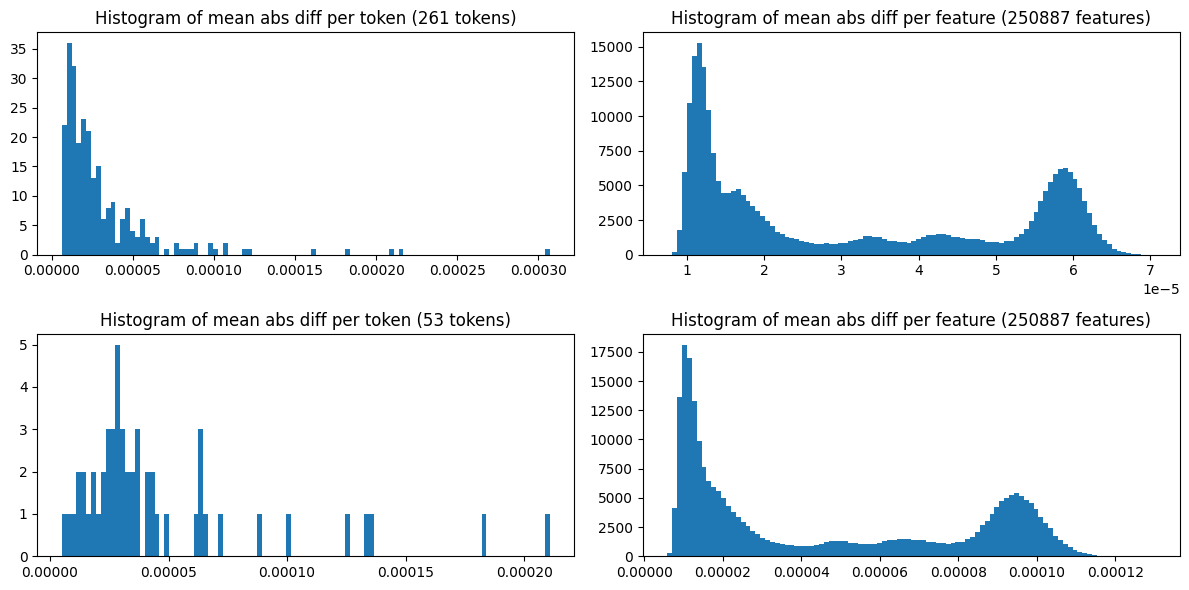

In [45]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.hist(diff2.mean(-1)[0].cpu().numpy(), bins=100);
plt.title(f"Histogram of mean abs diff per token ({len(inputs2['input_ids'][0])} tokens)");

plt.subplot(2,2,2)
plt.hist(diff2.mean(-2).mean(0).cpu().numpy(), bins=100);
plt.title(f"Histogram of mean abs diff per feature ({diff2.mean(-2).mean(0).cpu().numpy().shape[0]} features)");

plt.subplot(2,2,3)
plt.hist(diff.mean(-1)[0].cpu().numpy(), bins=100);
plt.title(f"Histogram of mean abs diff per token ({len(inputs['input_ids'][0])} tokens)");

plt.subplot(2,2,4)
plt.hist(diff.mean(-2).mean(0).cpu().numpy(), bins=100);
plt.title(f"Histogram of mean abs diff per feature ({diff.mean(-2).mean(0).cpu().numpy().shape[0]} features)");
plt.tight_layout()

In [4]:
merged_weight_diffs = []
unmerged_weight_diffs = []
layer_names = []

with torch.no_grad():
    for (n1, p1), (n2, p2) in zip(base_model.named_parameters(), merged_model.named_parameters()):
        if p1.shape == p2.shape:
            diff = (p1 - p2).abs().mean().item()
            merged_weight_diffs.append(diff)
            layer_names.append(n1)
        else:
            print(f"Skipping {n1} due to shape mismatch: {p1.shape} vs {p2.shape}")

Skipping model.embed_tokens.weight due to shape mismatch: torch.Size([250880, 4096]) vs torch.Size([250887, 4096])
Skipping lm_head.weight due to shape mismatch: torch.Size([250880, 4096]) vs torch.Size([250887, 4096])


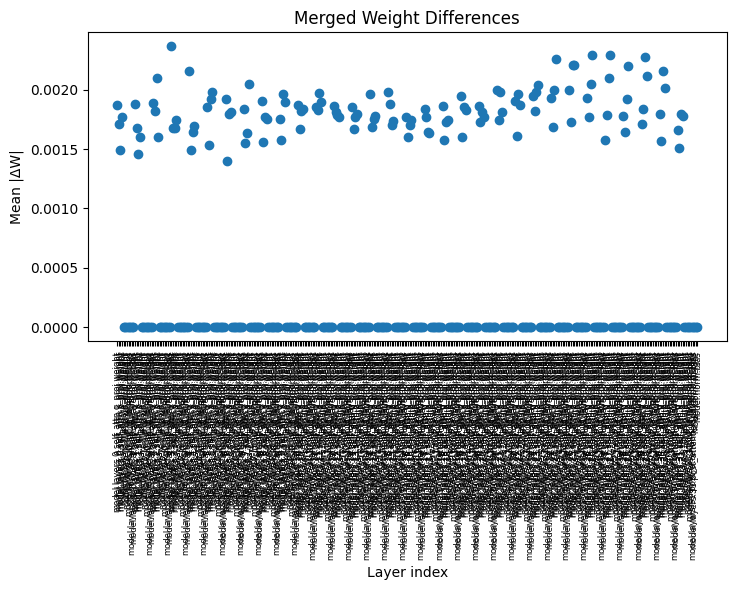

In [5]:
# ---- Plot ----
plt.figure(figsize=(14,6))

# Plot weight differences
plt.subplot(1,2,1)
plt.scatter(range(len(merged_weight_diffs)), merged_weight_diffs, marker='o')
plt.xticks(range(len(layer_names)), layer_names, rotation=90, fontsize=6)
plt.title("Merged Weight Differences")
plt.xlabel("Layer index")
plt.ylabel("Mean |ΔW|")
plt.tight_layout()



In [6]:
for i in range(len(merged_weight_diffs)):
    print(f"{layer_names[i]} --> Weight Diff = {merged_weight_diffs[i]:.6f}")

model.layers.0.self_attn.q_proj.weight --> Weight Diff = 0.001869
model.layers.0.self_attn.k_proj.weight --> Weight Diff = 0.001713
model.layers.0.self_attn.v_proj.weight --> Weight Diff = 0.001491
model.layers.0.self_attn.o_proj.weight --> Weight Diff = 0.001768
model.layers.0.mlp.gate_proj.weight --> Weight Diff = 0.000000
model.layers.0.mlp.up_proj.weight --> Weight Diff = 0.000000
model.layers.0.mlp.down_proj.weight --> Weight Diff = 0.000000
model.layers.0.input_layernorm.weight --> Weight Diff = 0.000000
model.layers.0.input_layernorm.bias --> Weight Diff = 0.000000
model.layers.0.post_attention_layernorm.weight --> Weight Diff = 0.000000
model.layers.0.post_attention_layernorm.bias --> Weight Diff = 0.000000
model.layers.1.self_attn.q_proj.weight --> Weight Diff = 0.001880
model.layers.1.self_attn.k_proj.weight --> Weight Diff = 0.001682
model.layers.1.self_attn.v_proj.weight --> Weight Diff = 0.001460
model.layers.1.self_attn.o_proj.weight --> Weight Diff = 0.001605
model.layer

In [4]:
merged_weight_diffs = []
peft_weight_diffs = []
layer_names = []

with torch.no_grad():
    for (n1, p1), (n2, p2) in zip(base_model.named_parameters(), peft_model.named_parameters()):
        if p1.shape == p2.shape:
            diff = (p1 - p2).abs().mean().item()
            peft_weight_diffs.append(diff)
            layer_names.append(n1)
        else:
            print(f"Skipping {n1} due to shape mismatch: {p1.shape} vs {p2.shape}")

Skipping model.layers.0.self_attn.k_proj.weight due to shape mismatch: torch.Size([1024, 4096]) vs torch.Size([16, 4096])
Skipping model.layers.0.self_attn.v_proj.weight due to shape mismatch: torch.Size([1024, 4096]) vs torch.Size([4096, 16])
Skipping model.layers.0.self_attn.o_proj.weight due to shape mismatch: torch.Size([4096, 4096]) vs torch.Size([1024, 4096])
Skipping model.layers.0.mlp.gate_proj.weight due to shape mismatch: torch.Size([14336, 4096]) vs torch.Size([16, 4096])
Skipping model.layers.0.mlp.up_proj.weight due to shape mismatch: torch.Size([14336, 4096]) vs torch.Size([1024, 16])
Skipping model.layers.0.mlp.down_proj.weight due to shape mismatch: torch.Size([4096, 14336]) vs torch.Size([1024, 4096])
Skipping model.layers.0.input_layernorm.weight due to shape mismatch: torch.Size([4096]) vs torch.Size([16, 4096])
Skipping model.layers.0.input_layernorm.bias due to shape mismatch: torch.Size([4096]) vs torch.Size([1024, 16])
Skipping model.layers.0.post_attention_layer

In [5]:
for i in range(len(peft_weight_diffs)):
    print(f"{layer_names[i]} --> Weight Diff = {peft_weight_diffs[i]:.6f}")

model.embed_tokens.weight --> Weight Diff = 0.000004
model.layers.0.self_attn.q_proj.weight --> Weight Diff = 0.000000
model.layers.1.input_layernorm.weight --> Weight Diff = 0.093773
model.layers.4.self_attn.o_proj.weight --> Weight Diff = 0.012429
model.layers.4.post_attention_layernorm.weight --> Weight Diff = 0.372779
model.layers.4.post_attention_layernorm.bias --> Weight Diff = 0.014618
model.layers.6.self_attn.q_proj.weight --> Weight Diff = 0.018011
model.layers.6.mlp.gate_proj.weight --> Weight Diff = 0.020288
model.layers.6.input_layernorm.weight --> Weight Diff = 0.685753
model.layers.6.input_layernorm.bias --> Weight Diff = 0.463637
model.layers.6.post_attention_layernorm.weight --> Weight Diff = 0.507857
model.layers.7.self_attn.v_proj.weight --> Weight Diff = 0.021340
model.layers.9.self_attn.v_proj.weight --> Weight Diff = 0.016973
model.layers.11.mlp.up_proj.weight --> Weight Diff = 0.020711
model.layers.11.input_layernorm.bias --> Weight Diff = 0.696819
model.layers.11

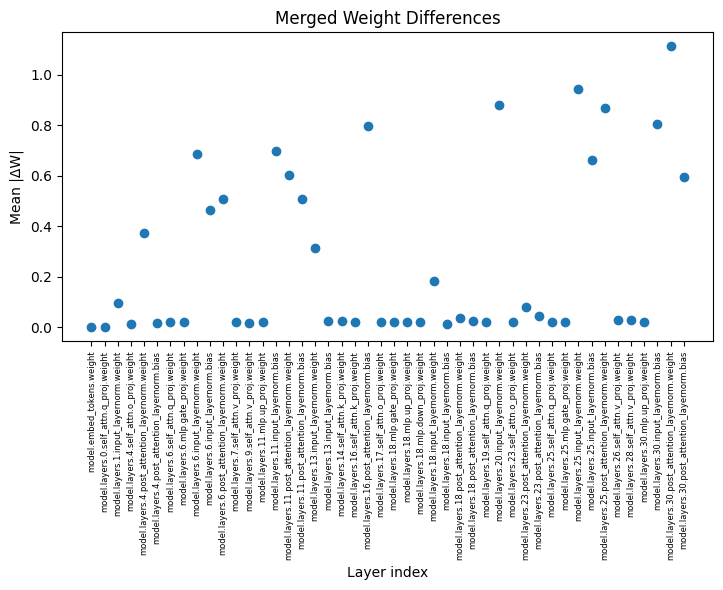

In [6]:
# ---- Plot ----
plt.figure(figsize=(14,6))

# Plot weight differences
plt.subplot(1,2,1)
plt.scatter(range(len(unmerged_weight_diffs)), unmerged_weight_diffs, marker='o')
plt.xticks(range(len(layer_names)), layer_names, rotation=90, fontsize=6)
plt.title("Merged Weight Differences")
plt.xlabel("Layer index")
plt.ylabel("Mean |ΔW|")
plt.tight_layout()



In [9]:
di = {}
for n1, p1 in peft_model.named_parameters():
    di[n1] = p1
    print(n1)

base_model.model.model.embed_tokens.weight
base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.o_proj.base_layer.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.gate_proj.weight
base_model.model.model.layers.0.mlp.up_proj.weight
base_model.model.

In [25]:
x = di["base_model.model.model.layers.4.self_attn.o_proj.lora_A.default.weight"]
x.shape

torch.Size([16, 4096])

In [26]:
y = di["base_model.model.model.layers.4.self_attn.o_proj.lora_B.default.weight"]
y.shape

torch.Size([4096, 16])

In [27]:
z = di["base_model.model.model.layers.4.self_attn.o_proj.base_layer.weight"]
z.shape

torch.Size([4096, 4096])

In [31]:
z

Parameter containing:
tensor([[ 8.3923e-05, -1.4954e-02,  1.4893e-02,  ...,  9.5825e-03,
          1.0742e-02, -3.2227e-02],
        [ 7.8125e-03, -1.1536e-02,  6.8970e-03,  ..., -1.7578e-02,
         -1.5076e-02,  3.0212e-03],
        [-1.9531e-02,  1.3306e-02, -1.2207e-02,  ...,  4.3030e-03,
          8.0566e-03,  1.3672e-02],
        ...,
        [ 3.2501e-03, -3.0823e-03, -1.7090e-03,  ...,  6.5308e-03,
         -1.3962e-03, -4.9133e-03],
        [ 5.6152e-03, -5.3711e-03, -4.1199e-03,  ..., -7.4158e-03,
          2.5482e-03,  6.5308e-03],
        [-2.3499e-03, -1.5335e-03, -1.5625e-02,  ...,  3.1982e-02,
          8.8501e-03, -1.0010e-02]], device='cuda:0')

In [46]:
delta = x.T @ y.T
delta

tensor([[-1.8512e-04, -5.7691e-05,  2.2438e-04,  ..., -2.9305e-04,
         -1.7932e-05,  7.1192e-05],
        [-2.8538e-04,  4.3974e-05,  6.6192e-05,  ...,  2.1066e-04,
         -2.8788e-04, -3.5276e-04],
        [-1.3372e-04, -2.2081e-04, -1.5635e-04,  ...,  5.1383e-05,
          1.1791e-04,  2.0954e-04],
        ...,
        [ 2.6060e-04,  6.7565e-05, -6.0168e-05,  ..., -1.7375e-04,
          6.6939e-04,  1.9023e-04],
        [ 2.6796e-04,  5.8405e-05, -1.8260e-04,  ..., -1.1807e-04,
          2.9330e-04,  2.5020e-04],
        [ 1.5722e-06,  1.2918e-04,  1.7273e-04,  ..., -2.2446e-04,
          4.1528e-04,  2.9591e-04]], device='cuda:0')

In [47]:
new_z = delta + z

In [36]:
base_di = {}
for n1, p1 in base_model.named_parameters():
    base_di[n1] = p1
    print(n1)

model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.o_proj.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.input_layernorm.bias
model.layers.0.post_attention_layernorm.weight
model.layers.0.post_attention_layernorm.bias
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.o_proj.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.input_layernorm.bias
model.layers.1.post_attention_layernorm.weight
model.layers.1.post_attention_layernorm.bias
model.layers.2.self_attn.q_proj.weight
model.layers.2.self_attn.k_proj.weight
model.layers.2.self_attn.v_proj.weight
m

In [50]:
reference = base_di["model.layers.4.self_attn.o_proj.weight"]

In [49]:
new_z

tensor([[-0.0001, -0.0150,  0.0151,  ...,  0.0093,  0.0107, -0.0322],
        [ 0.0075, -0.0115,  0.0070,  ..., -0.0174, -0.0154,  0.0027],
        [-0.0197,  0.0131, -0.0124,  ...,  0.0044,  0.0082,  0.0139],
        ...,
        [ 0.0035, -0.0030, -0.0018,  ...,  0.0064, -0.0007, -0.0047],
        [ 0.0059, -0.0053, -0.0043,  ..., -0.0075,  0.0028,  0.0068],
        [-0.0023, -0.0014, -0.0155,  ...,  0.0318,  0.0093, -0.0097]],
       device='cuda:0')

In [54]:
new_z- reference

tensor([[-1.8512e-04, -5.7691e-05,  2.2438e-04,  ..., -2.9305e-04,
         -1.7932e-05,  7.1194e-05],
        [-2.8538e-04,  4.3974e-05,  6.6191e-05,  ...,  2.1066e-04,
         -2.8788e-04, -3.5276e-04],
        [-1.3372e-04, -2.2081e-04, -1.5635e-04,  ...,  5.1383e-05,
          1.1791e-04,  2.0954e-04],
        ...,
        [ 2.6060e-04,  6.7565e-05, -6.0168e-05,  ..., -1.7375e-04,
          6.6939e-04,  1.9023e-04],
        [ 2.6796e-04,  5.8405e-05, -1.8260e-04,  ..., -1.1807e-04,
          2.9330e-04,  2.5020e-04],
        [ 1.5721e-06,  1.2918e-04,  1.7273e-04,  ..., -2.2446e-04,
          4.1528e-04,  2.9591e-04]], device='cuda:0', grad_fn=<SubBackward0>)

# systematic check

In [ ]:
import torch
# torch.manual_seed(42)
# torch.cuda.manual_seed_all(42)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel, PeftConfig
import torch, copy

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) load base model & tokenizer
model_name = "Behzadshomali/Teuken3.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True, trust_remote_code=True)
base = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)

should_setup_chat_format = False
if tokenizer.chat_template is None:
    from trl import setup_chat_format
    base, tokenizer = setup_chat_format(base, tokenizer)
    should_setup_chat_format = True
base.eval()

# 2) load LoRA adapter as a PeftModel wrapper (runtime adapter)
lora_id = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-30000/"
model_with_adapter = PeftModel.from_pretrained(base.to(device), lora_id).to(device)
model_with_adapter.eval()

# 3) prepare same input for both runs
input_text = "The cat sat on the"
inputs = tokenizer(input_text, return_tensors="pt").to(device)

# forward with runtime adapter
with torch.no_grad():
    out_runtime = model_with_adapter(**inputs, output_hidden_states=False, return_dict=True)
    logits_runtime = out_runtime.logits.cpu()

# 4) create a copy of base and merge LoRA into it (PEFT has merge_and_unload)
# IMPORTANT: reload base fresh to avoid in-place contamination
base_for_merge = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
if should_setup_chat_format:
    tokenizer.chat_template = None
    base_for_merge, _ = setup_chat_format(base_for_merge, tokenizer)
base_for_merge.eval()

# load adapter into a PeftModel which we will merge
peft_for_merge = PeftModel.from_pretrained(base_for_merge, lora_id)
peft_for_merge.eval()

# merge and unload modifies weights in-place and removes LoRA params
peft_for_merge = peft_for_merge.merge_and_unload()  # returns base model with merged weights in PEFT >= version

with torch.no_grad():
    peft_for_merge = peft_for_merge.to(device)
    out_merged = peft_for_merge(**inputs, output_hidden_states=False, return_dict=True)
    logits_merged = out_merged.logits.cpu()


/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added 

In [3]:
# 5) compare
diff = (logits_runtime - logits_merged).abs()
print("max abs diff logits:", diff.max().item())
print("mean abs diff logits:", diff.mean().item())

max abs diff logits: 0.00013589859008789062
mean abs diff logits: 1.1268255548202433e-05


In [5]:
import torch

def get_lora_effective_weight(layer: torch.nn.Module, adapter_name="default"):
    """
    Compute effective weight for a PEFT LoRA layer:
        W_eff = W_base + scaling * (B @ A)
    """
    # base weight
    W_base = layer.weight.detach().cpu()

    # No LoRA on this layer
    if not hasattr(layer, "lora_A") or adapter_name not in layer.lora_A:
        return W_base

    # Get low-rank factors
    A = layer.lora_A[adapter_name].weight.detach().cpu()   # shape [r, in_features]
    B = layer.lora_B[adapter_name].weight.detach().cpu()   # shape [out_features, r]

    # scaling factor
    scaling = layer.scaling[adapter_name]

    # Compute update
    delta_W = B @ A       # shape [out_features, in_features]
    delta_W = delta_W * scaling

    return W_base + delta_W


In [6]:
def compare_runtime_vs_merged(model_with_adapter, peft_for_merge, adapter_name="default", atol=1e-6):
    """
    model_with_adapter: PeftModel with LoRA adapter loaded at runtime
    peft_for_merge: PeftModel after merge_and_unload() (base model with merged weights)
    
    """
    diffs = {}
    merged_params = dict(peft_for_merge.named_parameters())

    for name, param in model_with_adapter.named_parameters():
        layer = dict(model_with_adapter.named_modules()).get(name.rsplit(".", 2)[0], None)
        # print(name)
        # Default: use the param directly
        W_eff = param.detach().cpu()

        # If the parent layer has LoRA, compute effective weight
        if layer is not None and hasattr(layer, f"lora_A") and adapter_name in layer.lora_A:
            W_eff = get_lora_effective_weight(layer, adapter_name=adapter_name)
            name = name.rsplit(".", 2)[0] + ".weight"

        # Compare with merged model’s param
        name = name.replace("base_model.model.", "")
        if name in merged_params:
            W_merged = merged_params[name].detach().cpu()
            max_diff = (W_eff - W_merged).abs().mean().item()
            # if max_diff > atol:
            diffs[name] = max_diff

    return diffs


In [7]:
# diffs = compare_runtime_vs_merged(model_with_adapter, peft_for_merge)
diffs = compare_runtime_vs_merged(base_model, merged_model)
sorted_diffs = dict(sorted(diffs.items(), key=lambda item: item[1], reverse=True))
for name, value in sorted_diffs.items():
    print(f"{name}: {value}")


model.layers.1.post_attention_layernorm.bias: 0.006933066062629223
model.layers.1.self_attn.q_proj.weight: 0.00655184593051672
model.layers.3.post_attention_layernorm.bias: 0.006106203887611628
model.layers.8.post_attention_layernorm.bias: 0.005807442590594292
model.layers.4.post_attention_layernorm.bias: 0.00571615993976593
model.layers.0.post_attention_layernorm.bias: 0.005666202865540981
model.layers.7.post_attention_layernorm.bias: 0.005540555343031883
model.layers.6.post_attention_layernorm.bias: 0.005387191195040941
model.layers.2.post_attention_layernorm.bias: 0.005233848467469215
model.layers.3.self_attn.q_proj.weight: 0.005166367162019014
model.layers.2.self_attn.q_proj.weight: 0.0050975242629647255
model.layers.5.post_attention_layernorm.bias: 0.004875044338405132
model.layers.9.post_attention_layernorm.bias: 0.00483895605430007
model.layers.29.self_attn.o_proj.weight: 0.004759655334055424
model.layers.10.post_attention_layernorm.bias: 0.004501204937696457
model.layers.27.sel

In [8]:
diffs = compare_runtime_vs_merged(peft_model, merged_model)
sorted_diffs = dict(sorted(diffs.items(), key=lambda item: item[1], reverse=False))
for name, value in sorted_diffs.items():
    print(f"{name}: {value}")

model.embed_tokens.weight: 0.0
model.layers.0.self_attn.q_proj.weight: 0.0
model.layers.0.self_attn.k_proj.weight: 0.0
model.layers.0.self_attn.v_proj.weight: 0.0
model.layers.0.self_attn.o_proj.weight: 0.0
model.layers.0.mlp.gate_proj.weight: 0.0
model.layers.0.mlp.up_proj.weight: 0.0
model.layers.0.mlp.down_proj.weight: 0.0
model.layers.1.self_attn.q_proj.weight: 0.0
model.layers.1.self_attn.k_proj.weight: 0.0
model.layers.1.self_attn.v_proj.weight: 0.0
model.layers.1.self_attn.o_proj.weight: 0.0
model.layers.1.mlp.gate_proj.weight: 0.0
model.layers.1.mlp.up_proj.weight: 0.0
model.layers.1.mlp.down_proj.weight: 0.0
model.layers.2.self_attn.q_proj.weight: 0.0
model.layers.2.self_attn.k_proj.weight: 0.0
model.layers.2.self_attn.v_proj.weight: 0.0
model.layers.2.self_attn.o_proj.weight: 0.0
model.layers.2.mlp.gate_proj.weight: 0.0
model.layers.2.mlp.up_proj.weight: 0.0
model.layers.2.mlp.down_proj.weight: 0.0
model.layers.3.self_attn.q_proj.weight: 0.0
model.layers.3.self_attn.k_proj.we

In [8]:
diffs = compare_runtime_vs_merged(merged_model, base_model)
sorted_diffs = dict(sorted(diffs.items(), key=lambda item: item[1], reverse=False))
for name, value in sorted_diffs.items():
    print(f"{name}: {value}")

model.layers.0.mlp.gate_proj.weight: 0.0
model.layers.0.mlp.up_proj.weight: 0.0
model.layers.0.mlp.down_proj.weight: 0.0
model.layers.0.input_layernorm.weight: 0.0
model.layers.0.input_layernorm.bias: 0.0
model.layers.0.post_attention_layernorm.weight: 0.0
model.layers.0.post_attention_layernorm.bias: 0.0
model.layers.1.mlp.gate_proj.weight: 0.0
model.layers.1.mlp.up_proj.weight: 0.0
model.layers.1.mlp.down_proj.weight: 0.0
model.layers.1.input_layernorm.weight: 0.0
model.layers.1.input_layernorm.bias: 0.0
model.layers.1.post_attention_layernorm.weight: 0.0
model.layers.1.post_attention_layernorm.bias: 0.0
model.layers.2.mlp.gate_proj.weight: 0.0
model.layers.2.mlp.up_proj.weight: 0.0
model.layers.2.mlp.down_proj.weight: 0.0
model.layers.2.input_layernorm.weight: 0.0
model.layers.2.input_layernorm.bias: 0.0
model.layers.2.post_attention_layernorm.weight: 0.0
model.layers.2.post_attention_layernorm.bias: 0.0
model.layers.3.mlp.gate_proj.weight: 0.0
model.layers.3.mlp.up_proj.weight: 0.0

In [43]:
adapter_name="default"

diffs = {}
merged_params = dict(peft_for_merge.named_parameters())

for name, param in model_with_adapter.named_parameters():
    layer = dict(model_with_adapter.named_modules()).get(name.rsplit(".", 2)[0], None)
    # print(name)
    # Default: use the param directly
    W_eff = param.detach().cpu()

    # If the parent layer has LoRA, compute effective weight
    if layer is not None and hasattr(layer, f"lora_A") and adapter_name in layer.lora_A:
        W_eff = get_lora_effective_weight(layer, adapter_name=adapter_name)
        name = name.rsplit(".", 2)[0] + ".weight"
    else:
        print(name)

    # Compare with merged model’s param
    name = name.replace("base_model.model.", "")
    if name in merged_params:
        W_merged = merged_params[name].detach().cpu()
        max_diff = (W_eff - W_merged).abs().mean().item()
        # if max_diff > atol:
        diffs[name] = max_diff

base_model.model.model.embed_tokens.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.gate_proj.weight
base_model.model.model.layers.0.mlp.up_proj.weight
base_model.model.model.layers.0.mlp.down_proj.weight
base_model.model.model.layers.0.input_layernorm.weight
base_model.model.model.layers.0.input_layernorm.bias
base_model.model.model.layers.0.post_attention_layernorm.weight
base_model.model.model.layers.0.post_attention_layernorm.bia

In [40]:
W_merged

tensor([[ 0.0547,  0.0303, -0.0119,  ...,  0.0325,  0.0337, -0.0259],
        [ 0.0503, -0.0036, -0.0151,  ...,  0.0195,  0.0361, -0.0212],
        [ 0.0498,  0.0339,  0.0231,  ...,  0.0062, -0.0179, -0.0376],
        ...,
        [-0.0439, -0.1040,  0.0014,  ...,  0.0134,  0.0708, -0.0596],
        [-0.0439, -0.1040,  0.0015,  ...,  0.0134,  0.0708, -0.0596],
        [-0.0439, -0.1040,  0.0015,  ...,  0.0134,  0.0708, -0.0596]])

In [41]:
W_eff

tensor([[ 0.0547,  0.0303, -0.0119,  ...,  0.0325,  0.0337, -0.0259],
        [ 0.0503, -0.0036, -0.0151,  ...,  0.0195,  0.0361, -0.0212],
        [ 0.0498,  0.0339,  0.0231,  ...,  0.0062, -0.0179, -0.0376],
        ...,
        [-0.0439, -0.1040,  0.0014,  ...,  0.0134,  0.0708, -0.0596],
        [-0.0439, -0.1040,  0.0015,  ...,  0.0134,  0.0708, -0.0596],
        [-0.0439, -0.1040,  0.0015,  ...,  0.0134,  0.0708, -0.0596]])

In [35]:
merged_params.keys()

dict_keys(['model.embed_tokens.weight', 'model.layers.0.self_attn.q_proj.weight', 'model.layers.0.self_attn.k_proj.weight', 'model.layers.0.self_attn.v_proj.weight', 'model.layers.0.self_attn.o_proj.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.input_layernorm.bias', 'model.layers.0.post_attention_layernorm.weight', 'model.layers.0.post_attention_layernorm.bias', 'model.layers.1.self_attn.q_proj.weight', 'model.layers.1.self_attn.k_proj.weight', 'model.layers.1.self_attn.v_proj.weight', 'model.layers.1.self_attn.o_proj.weight', 'model.layers.1.mlp.gate_proj.weight', 'model.layers.1.mlp.up_proj.weight', 'model.layers.1.mlp.down_proj.weight', 'model.layers.1.input_layernorm.weight', 'model.layers.1.input_layernorm.bias', 'model.layers.1.post_attention_layernorm.weight', 'model.layers.1.post_attention_layernorm.bias', 'model.layers.2.self_attn.q_proj.weigh

In [39]:
# sort diffs by value
sorted_diffs = dict(sorted(diffs.items(), key=lambda item: item[1], reverse=True))
for name, value in sorted_diffs.items():
    print(f"{name}: {value}")

model.embed_tokens.weight: 0.0
model.layers.0.self_attn.q_proj.weight: 0.0
model.layers.0.self_attn.k_proj.weight: 0.0
model.layers.0.self_attn.v_proj.weight: 0.0
model.layers.0.self_attn.o_proj.weight: 0.0
model.layers.0.mlp.gate_proj.weight: 0.0
model.layers.0.mlp.up_proj.weight: 0.0
model.layers.0.mlp.down_proj.weight: 0.0
model.layers.0.input_layernorm.weight: 0.0
model.layers.0.input_layernorm.bias: 0.0
model.layers.0.post_attention_layernorm.weight: 0.0
model.layers.0.post_attention_layernorm.bias: 0.0
model.layers.1.self_attn.q_proj.weight: 0.0
model.layers.1.self_attn.k_proj.weight: 0.0
model.layers.1.self_attn.v_proj.weight: 0.0
model.layers.1.self_attn.o_proj.weight: 0.0
model.layers.1.mlp.gate_proj.weight: 0.0
model.layers.1.mlp.up_proj.weight: 0.0
model.layers.1.mlp.down_proj.weight: 0.0
model.layers.1.input_layernorm.weight: 0.0
model.layers.1.input_layernorm.bias: 0.0
model.layers.1.post_attention_layernorm.weight: 0.0
model.layers.1.post_attention_layernorm.bias: 0.0
mod